<a href="https://colab.research.google.com/github/Apoorv070/AI-Agent-Revison-Notebooks/blob/main/6_Multi_Agent_System_Contd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -qU langchain langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 27.8 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [3]:
from typing_extensions import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
import operator
from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END

In [4]:
class TeamState(TypedDict):
    topic: str
    research_notes: str
    draft: Annotated[list[str], operator.add]
    reviews: Annotated[list[str], operator.add]
    reason: str
    stage: str
    next_agent: str

    logs: Annotated[list[str], operator.add]
    view_logs: Annotated[list[str], operator.add]

In [5]:
class ManagerDecision(BaseModel):
  next_agent: Literal["researcher_node", "writer_node", "reviewer_node", "END"] = Field(description  = "Next node chosen by Manager")
  reason:str =  Field(description = "Short Reason for handover")

class ResearchOutput(BaseModel):
  research_notes: str = Field(description = "Research notes")

class WriterOutput(BaseModel):
  draft:str = Field(description = "Draft reel content created by Writer")

class ReviewerOutput(BaseModel):
  reviews: str = Field(description = "Reviewer comments and feedback on the draft")
  # stage: str = Literal["review pass", "review revision"] = Field(description  = Next node chosen by Manager")
  stage: Literal["review pass", "review revision"] = Field(description  = "The stage chosen by reviewer")



In [6]:
# output = manager_agent.invoke({"messages" : [{"role": "user","content": (f"Topic: Write about Recommendation systems\n"
#             f"Choose the next node") }]})
# output['structured_response'].next_agent

In [7]:
manager_agent = create_agent(
    model = "openai:gpt-4o-mini",
    response_format = ManagerDecision,
    system_prompt = (
        "You are the manager of a small content team.\n"
        "Routing rules:\n"
        "- If stage is 'start' -> researcher_node\n"
        "- If stage is 'researched' -> writer_node\n"
        "- If stage is 'drafted' -> reviewer_node\n"
        "- If stage is 'review revision' -> writer_node\n"
        "- If stage is 'review pass' -> END\n"
        "Return only the next node and a short reason."
    )

)

research_agent = create_agent(
    model = "openai:gpt-4o-mini",
    response_format = ResearchOutput,
    system_prompt = (
        "You are a researcher.\n"
        "Given a topic, create short practical notes.\n"
        "Keep it simple and useful for a reels content writer."
    )

)


writer_agent = create_agent(
    model = "openai:gpt-4o-mini",
    response_format = WriterOutput,
    system_prompt = (
        "You are a reel content writer.\n"
        "You will receive topic, research notes, and conversation history. - You will received history of your messages(assistant), and reviewer comments on those messages\n"
        "If there is no draft history, write the first draft.\n"
        "Try to be extravagant and over-claiming in your content"
        "If there is history, improve the draft using reviewer feedback.\n"
        "Keep it short, punchy, and easy to speak."
    )

)


reviewer_agent = create_agent(
    model = "openai:gpt-4o-mini",
    response_format = ReviewerOutput,
    system_prompt = (
        "You are a reviewer.\n"
        "Review on exaggeration, bias, clarity, tone, and overclaiming.\n"
        "Give short usable feedback."
        "Return final answer as `review revision` or `review pass`"
    )

)

In [8]:
# {"messages": [{"role": "user", "content": ""}]}
def manager_node(state: TeamState):
  view = {"topic": state["topic"], "stage": state["stage"]}
  result = manager_agent.invoke({"messages" : [{"role": "user","content": (f"Topic: {view["topic"]}\n"
            f"Stage: {view["stage"]}"
            f"Choose the next node") }]})
  output = result['structured_response']
  print(output)

  return {"next_agent": output.next_agent,
          "reason": output.reason,
          "logs": [f"Manager -> {output.next_agent} | {output.reason}"],
          "view_logs": [f"Manager's view -> {view}"]
          }

In [9]:
def researcher_node(state: TeamState):
  view = {"topic": state["topic"]}
  result = research_agent.invoke({"messages": [{"role": "user", "content": f"Topic: {view["topic"]}"}]})
  output = result['structured_response']

  return {"research_notes": output.research_notes,
          "stage": "researched",
          "logs": ["Researcher -> Manager | research notes prepared"],
          "view_logs": [f"Researcher View - {view}"]
          }

In [ ]:
state = {"draft": ["idhlddlhdlkhdlhd;d", "ldkhldkshlsdkhdslkhsd", "ldkhslkhslkhdslkhd"],
         "review":["lskdhlskhsdlksdhldskhsd", "lskdhdslkhsdlkhsdlkd", "sdlkhslkhdslksdh"]}

In [ ]:
val = list(state.values())
tuple(zip(val[0], val[1]))

(('idhlddlhdlkhdlhd;d', 'lskdhlskhsdlksdhldskhsd'),
 ('ldkhldkshlsdkhdslkhsd', 'lskdhdslkhsdlkhsdlkd'),
 ('ldkhslkhslkhdslkhd', 'sdlkhslkhdslksdh'))

In [10]:
import itertools

def get_view_history(state):
    # Extract lists, defaulting to empty lists if the keys are missing
    drafts = state.get("draft", [])
    reviews = state.get("review", [])

    formatted_lines = []

    # zip_longest pairs items up to the length of the longest list
    for draft_item, review_item in itertools.zip_longest(drafts, reviews):
        # Add the draft item with the 'writer' role if it exists
        if draft_item is not None:
            formatted_lines.append(f"# assistant: {draft_item}")

        # Add the review item with the 'reviewer' role if it exists
        if review_item is not None:
            formatted_lines.append(f"# reviewer: {review_item}")

    # Join all lines together with a newline character
    return "\n".join(formatted_lines)

# --- Example Usage ---
state = {
    "draft": ["idhlddlhdlkhdlhd;d", "ldkhldkshlsdkhdslkhsd", "ldkhslkhslkhdslkhd", "extra_draft_item"],
    "review": ["lskdhlskhsdlksdhldskhsd", "lskdhdslkhsdlkhsdlkd", "sdlkhslkhdslksdh"]
}

result_string = get_view_history(state)
print(result_string)

# assistant: idhlddlhdlkhdlhd;d
# reviewer: lskdhlskhsdlksdhldskhsd
# assistant: ldkhldkshlsdkhdslkhsd
# reviewer: lskdhdslkhsdlkhsdlkd
# assistant: ldkhslkhslkhdslkhd
# reviewer: sdlkhslkhdslksdh
# assistant: extra_draft_item


In [11]:
def build_writer_view(state):
  return {"topic": state["topic"],
          "research_notes": state["research_notes"],
          "history": get_view_history(state)}

In [12]:
def writer_node(state: TeamState):
  view = build_writer_view(state)
  result = writer_agent.invoke({"messages": [{"role": "user",
                                               "content":
                                                (f"Topic: {view["topic"]}\n"
                                                f"History: {view["history"]}\n"
                                                f"research_notes: {view["research_notes"]}\n"
                                               )}]})
  output = result['structured_response']
  return {"draft": [output.draft],
          "stage": "drafted",
          "logs": [f"Writer -> Manager | Draft prepared"],
          "view_logs": [f"Writer View -> {view}"]}

In [13]:
def reviewer_node(state: TeamState):
  view = {'topic': state['topic'], 'draft': state['draft']}
  result = reviewer_agent.invoke({"messages": [{"role": "user",
                                               "content":
                                                (f"Topic: {view["topic"]}\n"
                                                f"draft: {view["draft"]}\n"
                                               )}]})
  output = result['structured_response']
  return {"reviews": [output.reviews],
          "stage": output.stage,
          "logs": ["Reviewer -> Manager| Review Done"],
          "view_logs": [f"reviewer view -> {view}"]}

In [14]:
def route_from_manager(state: TeamState):
  if(state['next_agent'] == "END"):
    return END
  return state["next_agent"]

In [15]:
del builder

NameError: name 'builder' is not defined

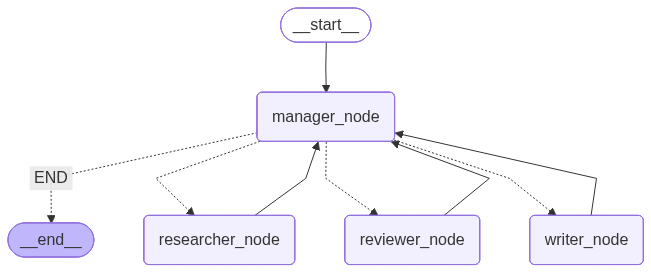

In [16]:
builder_new = StateGraph(TeamState)
builder_new.add_node("manager_node", manager_node)
builder_new.add_node("researcher_node", researcher_node)
builder_new.add_node("writer_node", writer_node)
builder_new.add_node("reviewer_node", reviewer_node)

builder_new.add_edge(START, "manager_node")
from langgraph.graph import StateGraph, START, END

def route_from_manager(state: TeamState):
    return state["next_agent"]   # should be one of:
                                 # "researcher_node", "writer_node", "reviewer_node", "END"

builder_new = StateGraph(TeamState)

builder_new.add_node("manager_node", manager_node)
builder_new.add_node("researcher_node", researcher_node)
builder_new.add_node("writer_node", writer_node)
builder_new.add_node("reviewer_node", reviewer_node)

builder_new.add_edge(START, "manager_node")

builder_new.add_conditional_edges(
    "manager_node",
    route_from_manager,
    {
        "researcher_node": "researcher_node",
        "writer_node": "writer_node",
        "reviewer_node": "reviewer_node",
        "END": END,
    }
)

builder_new.add_edge("researcher_node", "manager_node")
builder_new.add_edge("writer_node", "manager_node")
builder_new.add_edge("reviewer_node", "manager_node")

graph = builder_new.compile()
builder_new.add_edge("researcher_node", "manager_node")
builder_new.add_edge("writer_node", "manager_node")
builder_new.add_edge("reviewer_node", "manager_node")

graph = builder_new.compile()
graph

In [17]:
initial_state = {
    "topic": "How recommendation systems shape what people watch online",
    "research_notes": "",
    "draft": [],
    "reviews": [],
    "stage": "start",
    "next_agent": "",
    "logs": [],
    "view_logs": [],
}

out = manager_node(initial_state)
print(out)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
initial_state = {
    "topic": "How recommendation systems shape what people watch online",
    "research_notes": "",
    "draft": [],
    "reviews": [],
    "stage": "start",
    "next_agent": "",
    "logs": [],
    "view_logs": [],
}

for chunk in graph.stream(initial_state, stream_mode="updates", version="v2"):
    if chunk["type"] == "updates":
        print(chunk["data"])

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='researcher_node' reason='The content is in the initial stage, requiring research to gather relevant information.'
{'manager_node': {'next_agent': 'researcher_node', 'logs': ['Manager -> researcher_node | The content is in the initial stage, requiring research to gather relevant information.'], 'view_logs': ["Manager's view -> {'topic': 'How recommendation systems shape what people watch online', 'stage': 'start'}"]}}
{'researcher_node': {'research_notes': "1. **Definition**: Recommendation systems analyze users' preferences and behaviors to suggest content, significantly influencing what people watch online.\n\n2. **Types**: \n   - **Collaborative Filtering**: Analyzes user activity (who watched what) and recommends content based on similar users' preferences.\n   - **Content-Based Filtering**: Suggests videos similar to ones a user has liked or interacted with, based on attributes like genre, director, or keywords.\n   - **Hybrid Systems**: Combine collaborative and conten

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='writer_node' reason="The research is complete, and it's time for the writer to draft the content."
{'manager_node': {'next_agent': 'writer_node', 'logs': ["Manager -> writer_node | The research is complete, and it's time for the writer to draft the content."], 'view_logs': ["Manager's view -> {'topic': 'How recommendation systems shape what people watch online', 'stage': 'researched'}"]}}


TypeError: can only concatenate list (not "str") to list

In [ ]:
manager_node(initial_state)

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='researcher_node' reason="The project is at the 'start' stage, requiring initial research to gather information."


{'next_agent': 'researcher_node',
 'reason': "The project is at the 'start' stage, requiring initial research to gather information.",
 'logs': ["Manager -> researcher_node | The project is at the 'start' stage, requiring initial research to gather information."],
 'view_logs': ["Manager's view -> {'topic': 'How recommendation systems shape what people watch online', 'stage': 'start'}"]}

{'draft': ['idhlddlhdlkhdlhd;d',
  'ldkhldkshlsdkhdslkhsd',
  'ldkhslkhslkhdslkhd',
  'extra_draft_item'],
 'review': ['lskdhlskhsdlksdhldskhsd',
  'lskdhdslkhsdlkhsdlkd',
  'sdlkhslkhdslksdh']}

SyntaxError: unterminated string literal (detected at line 5) (2812693909.py, line 5)

In [ ]:
new_state = {'next_agent': 'researcher_node',
 'reason': "The project is at the 'start' stage, requiring initial research to gather information.",
 'logs': ["Manager -> researcher_node | The project is at the 'start' stage, requiring initial research to gather information."],
 'view_logs': ["Manager's view -> {'topic': 'How recommendation systems shape what people watch online', 'stage': 'start'}"]}

In [ ]:
route_from_manager(new_state)

'researcher_node'

In [ ]:
out = manager_node(initial_state)
print(out)

test_state = {**initial_state, **out}
print(route_from_manager(test_state))

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='researcher_node' reason='The topic needs to be researched before proceeding with writing.'
{'next_agent': 'researcher_node', 'reason': 'The topic needs to be researched before proceeding with writing.', 'logs': ['Manager -> researcher_node | The topic needs to be researched before proceeding with writing.'], 'view_logs': ["Manager's view -> {'topic': 'How recommendation systems shape what people watch online', 'stage': 'start'}"]}
researcher_node


In [ ]:
graph.invoke({
    "topic": "How recommendation systems shape what people watch online",
    "research_notes": "",
    "draft": [],
    "reviews": [],
    "stage": "start",
    "next_agent": "",
    "logs": [],
    "view_logs": [],
})

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='researcher_node' reason='The process is at the start stage, requiring initial research.'


/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='writer_node' reason="The stage is 'researched', so the next step is to have the content drafted."


TypeError: can only concatenate list (not "str") to list

In [ ]:
builder_new = StateGraph(TeamState)

builder_new.add_node("manager_node", manager_node)
builder_new.add_node("researcher_node", researcher_node)
builder_new.add_node("writer_node", writer_node)
builder_new.add_node("reviewer_node", reviewer_node)

builder_new.add_edge(START, "manager_node")

builder_new.add_conditional_edges(
    "manager_node",
    route_from_manager,
    {
        "researcher_node": "researcher_node",
        "writer_node": "writer_node",
        "reviewer_node": "reviewer_node",
        "END": END,
    }
)

builder_new.add_edge("researcher_node", "manager_node")
builder_new.add_edge("writer_node", "manager_node")
builder_new.add_edge("reviewer_node", "manager_node")

graph = builder_new.compile()

In [ ]:
result = graph.invoke(
    {
        "topic": "How recommendation systems shape what people watch online",
        "research_notes": "",
        "draft": [],
        "reviews": [],
        "stage": "start",
        "next_agent": "",
        "logs": [],
        "view_logs": [],
    }
)

result

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='researcher_node' reason='The research phase is required to gather information on how recommendation systems influence viewing habits.'


/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='writer_node' reason='The content has been researched and is ready for drafting.'


TypeError: can only concatenate list (not "str") to list

In [ ]:
state

{'draft': ['idhlddlhdlkhdlhd;d',
  'ldkhldkshlsdkhdslkhsd',
  'ldkhslkhslkhdslkhd',
  'extra_draft_item'],
 'review': ['lskdhlskhsdlksdhldskhsd',
  'lskdhdslkhsdlkhsdlkd',
  'sdlkhslkhdslksdh']}

In [ ]:
initial_state

{'topic': 'How recommendation systems shape what people watch online',
 'research_notes': '',
 'drafts': [],
 'reviews': [],
 'stage': 'start',
 'next_agent': 'researcher_node',
 'logs': ['Manager -> researcher_node | The project is at the beginning stage, so it needs research to gather relevant information.'],
 'view_logs': ["Manager's view -> {'topic': 'How recommendation systems shape what people watch online', 'stage': 'start'}"],
 'reason': 'The project is at the beginning stage, so it needs research to gather relevant information.'}

In [ ]:
manager_output = manager_node(initial_state)

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='researcher_node' reason='The topic is at the start stage and needs research to gather relevant information.'


In [ ]:
state = initial_state.copy()
state.update(manager_output)
state

{'topic': 'How recommendation systems shape what people watch online',
 'research_notes': '',
 'drafts': [],
 'reviews': [],
 'stage': 'start',
 'next_agent': 'researcher_node',
 'logs': ['Manager -> researcher_node | The topic is at the start stage and needs research to gather relevant information.'],
 'view_logs': ["Manager's view -> {'topic': 'How recommendation systems shape what people watch online', 'stage': 'start'}"],
 'reason': 'The topic is at the start stage and needs research to gather relevant information.'}

In [ ]:
researcher_output = researcher_node(state)
state.update(researcher_output)

In [ ]:
state

{'topic': 'How recommendation systems shape what people watch online',
 'research_notes': '1. **Personalization**: Recommendation systems analyze user behavior (views, likes, time spent) to curate personalized content. This keeps users engaged and increases viewing time.\n\n2. **Algorithms Used**: Common algorithms include collaborative filtering (based on user similarities) and content-based filtering (based on item features). Hybrid approaches often combine both.\n\n3. **Influence of Data**: The more data a platform collects, the better it can predict user preferences. This leads to higher accuracy in recommendations but also raises concerns about user privacy.\n\n4. **Content Discovery**: These systems help users discover new content they might not have searched for actively, which can promote lesser-known creators and media.\n\n5. **Feedback Loops**: Recommendation systems can create feedback loops, where popular content gets even more visibility, sometimes at the expense of divers

In [ ]:
manager_output = manager_node(state)
state.update(manager_output)
state

/usr/local/lib/python3.12/dist-packages/pydantic/json_schema.py:2442: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Next node chosen by Manager'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


next_agent='writer_node' reason="The research is complete, and it's time for the writer to create the draft."


{'topic': 'How recommendation systems shape what people watch online',
 'research_notes': '1. **Personalization**: Recommendation systems analyze user behavior (views, likes, time spent) to curate personalized content. This keeps users engaged and increases viewing time.\n\n2. **Algorithms Used**: Common algorithms include collaborative filtering (based on user similarities) and content-based filtering (based on item features). Hybrid approaches often combine both.\n\n3. **Influence of Data**: The more data a platform collects, the better it can predict user preferences. This leads to higher accuracy in recommendations but also raises concerns about user privacy.\n\n4. **Content Discovery**: These systems help users discover new content they might not have searched for actively, which can promote lesser-known creators and media.\n\n5. **Feedback Loops**: Recommendation systems can create feedback loops, where popular content gets even more visibility, sometimes at the expense of divers

In [ ]:
writer_output = writer_node(state)

In [ ]:
writer_output

{'draft': ['🎬 **How Recommendation Systems Shape Your Viewing Experience!**  \n  \nHey there! Ever wonder how Netflix knows what you want to watch next? 🤔 It all comes down to recommendation systems!  \n  \n1️⃣ **Personal Touch**: These systems track your views, likes, and even time spent on titles, creating a personalized playlist just for you! 📊   \n  \n2️⃣ **Smart Algorithms**: They use clever algorithms like collaborative filtering (finding pals with similar tastes) and content-based filtering (matching features). Sometimes they team up for the best of both worlds! 🤝  \n  \n3️⃣ **Data Power**: The more data they gather, the better your recommendations become! But there’s a catch — it raises questions about privacy. 🔒  \n  \n4️⃣ **Discover More**: Feeling adventurous? These systems help you discover hidden gems and support lesser-known creators. 🌟  \n  \n5️⃣ **Feedback Loops**: Popular shows get more airtime, which can limit your exposure to diverse content. Don’t let algorithm bias

In [ ]:
state.update(writer_output)

In [ ]:
state

{'topic': 'How recommendation systems shape what people watch online',
 'research_notes': '1. **Personalization**: Recommendation systems analyze user behavior (views, likes, time spent) to curate personalized content. This keeps users engaged and increases viewing time.\n\n2. **Algorithms Used**: Common algorithms include collaborative filtering (based on user similarities) and content-based filtering (based on item features). Hybrid approaches often combine both.\n\n3. **Influence of Data**: The more data a platform collects, the better it can predict user preferences. This leads to higher accuracy in recommendations but also raises concerns about user privacy.\n\n4. **Content Discovery**: These systems help users discover new content they might not have searched for actively, which can promote lesser-known creators and media.\n\n5. **Feedback Loops**: Recommendation systems can create feedback loops, where popular content gets even more visibility, sometimes at the expense of divers